##### Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path

from gg570_d200.auxiliary_functions.synthetic_funcs import synthetic_loop, prepare_heatmap, plot_heatmap
from gg570_d200.auxiliary_functions.overlap_funcs import overlap_measures

In [2]:
root = Path.cwd().parent
data_path = root / "data"

---

##### Synthetic measures

###### Set-up

In [3]:
np.random.seed(21)

In [4]:
df_scaled = pd.read_csv(data_path / "df_scaled.csv")

In [5]:
treatment_col = 'Training (last 3 months)'
outcome_col = 'Underemployment hours'
covariate_cols = [col for col in df_scaled.columns if col not in treatment_col and col not in outcome_col and col not in ['prop_scores']]

In [6]:
true_extreme_scores_perc, true_ess_perc = overlap_measures(df_scaled, treatment_col, 'prop_scores')

###### Loop

In [ ]:
iterations = 1600
synthetic_ate = 10
# The number of iterations is chosen to be computationally manageable,
# and because results will be binned into 16 bin,
# the average bin will consider 100 iterations, which is deemed sufficient for stable results.
# The synthetic (homogeneous) ATE is chosen arbitrarily.
# It is close to the mean of the outcome variable in the original data.

In [ ]:
iterations_dict = synthetic_loop(df_scaled, covariate_cols, iterations, synthetic_ate, root, cross_fit=True)
# The synthetic loop is a helper function estimating the ATE over synthetic data in each iteration,
# using the ForestRiesz and the plug-in method

1
160
320
480
640
800
960
1120
1280
1440
1600


In [ ]:
bins_per_overlap_measure = 4
# 4 bins defining relative effective sample size,
# and 4 bins defining percentage of extreme propensity scores,
# resulting in 16 bins in total.

In [ ]:
data_matrix, str_matrix, true_bin_i, true_bin_j, extreme_scores_categories, ess_categories = prepare_heatmap(iterations_dict, synthetic_ate, true_extreme_scores_perc, true_ess_perc, bins_per_overlap_measure)
# A helper function is use to prepare the data for the heatmap generated below,
# including the data considered for colouring and the annotations.

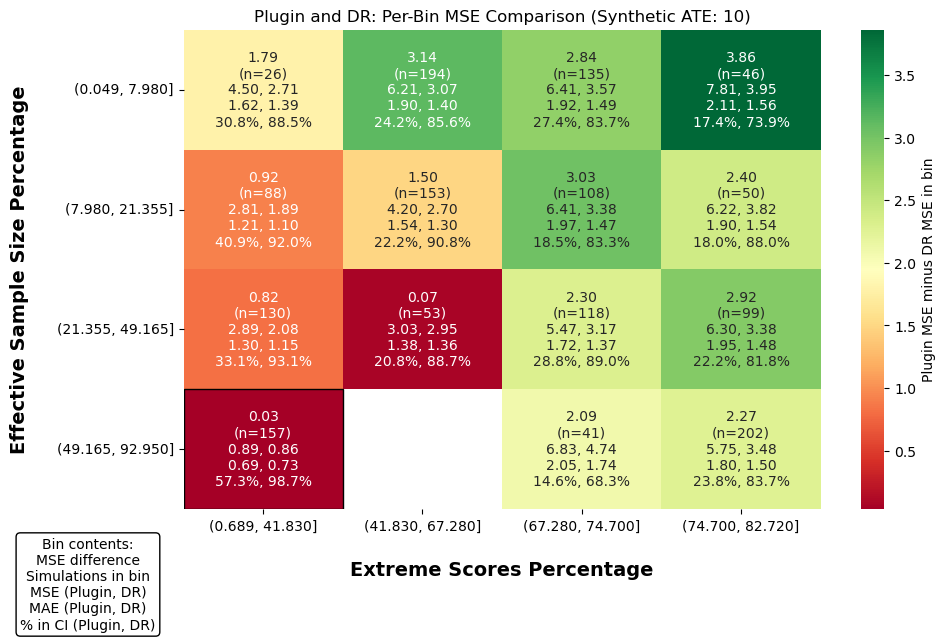

In [ ]:
plot_heatmap(data_matrix, str_matrix, true_bin_i, true_bin_j, extreme_scores_categories, ess_categories, synthetic_ate, root)
# Another helper function is used to plot the relevant heatmap.